## Analiza cen na rynku samochodów w Indiach.
W ramach projektu wybraliśmy zbiór danych znajdujący się pod adresem: https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?resource=download&select=Car+details+v3.csv

Zbiór danych zawiera informacje o używanych samochodach, wystawionych na sprzedaż w serwisie Cardekho.com. Składa się z 8128 wierszy i 13 kolumn. Jest on często wykorzystywany do zadań związanych z predykcją cen, co stanowi dobry przykład zastosowania regresji liniowej w uczeniu maszynowym.

Głównym tematem zadania jest sprawdzenie wpływu różnych czynników (ilość właścicieli, pojemność skokowa, przebieg itp.) na cenę końcową sprzedaży samochodów na terenie Indii.  

Zbiór danych zawiera następujące zmienne:

    name: Nazwa i model samochodu

    year: Rok zakupu samochodu

    selling_price: Cena sprzedaży samochodu (zmienna docelowa - zmienna ta będzie pełnić rolę zmiennej objaśnianej)

    km_driven: Liczba przejechanych kilometrów

    fuel: Rodzaj paliwa (diesel, benzyna, CNG, LPG)

    seller_type: Typ sprzedawcy (osoba prywatna, dealer)

    transmission: Skrzynia biegów (manualna, automatyczna)

    owner: Liczba poprzednich właścicieli

    mileage: Przebieg (wydajność spalania paliwa)

    engine: Pojemność silnika (CC)

    max_power: Moc silnika (BHP)

    torque: Moment obrotowy

    seats: Liczba miejsc

Dane numeryczne: Kolumny takie jak 'year', 'selling_price', 'km_driven' i 'seats' są w formacie numerycznym.

Dane tekstowe: Kolumny 'name', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power' i 'torque' są w formacie tekstowym i wymagają konwersji do formatu numerycznego w celu przeprowadzenia analizy statystycznej.

Brakujące wartości: W zbiorze danych występują brakujące wartości w kolumnach 'mileage', 'engine', 'max_power' i 'seats', które stanowią około 3% danych.

## Przygotowanie Zbioru Danych

In [1]:
%pip install --quiet matplotlib pandas numpy seaborn scikit-learn scipy
# w przypadku używania pliku w Google Colab, należy usunąć tą komórkę lub jej nie wykonywać, ja robie to w vscode

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import datetime
from matplotlib.ticker import FuncFormatter
import scipy
df = pd.read_csv('Car details v3.csv',delimiter=',')
CURRENT_YEAR = datetime.date.today().year
print(df.head(5))

                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner     mileage   engine   max_power  \
0  Individual       Manual   First Owner   23.4 kmpl  1248 CC      74 bhp   
1  Individual       Manual  Second Owner  21.14 kmpl  1498 CC  103.52 bhp   
2  Individual       Manual   Third Owner   17.7 kmpl  1497 CC      78 bhp   
3  Individual       Manual   First Owner   23.0 kmpl  1396 CC      90 bhp   
4  Individual       Manual   First Owner   16.1 kmpl  1298 CC    88.2 bhp   

                     torque  seats  
0            190Nm@ 2000rpm    5.0  
1       250N

Czyszczenie danych - usuwanie wartości NaN:

In [3]:
#sprawdzenie kształtu danych
print(f"Kształt danych przed czysczeniem: {df.shape}")
#sprawdzenie NaN
print(df.isnull().sum())
init_rows = len(df)
#czyszczenie kolumn zbioru danych
df.dropna(subset=['selling_price', 'mileage', 'engine', 'max_power', 'torque', 'seats'], inplace=True)
df.reset_index(drop=True,inplace=True)
modded_rows = len(df)

print(f"\nUsunięto {init_rows - modded_rows} wierszy z powodu NaN w kluczowych kolumnach.")
print(f"\nKształt danych po czyszczeniu: {df.shape}")

Kształt danych przed czysczeniem: (8128, 13)
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

Usunięto 222 wierszy z powodu NaN w kluczowych kolumnach.

Kształt danych po czyszczeniu: (7906, 13)


Konwersja poszczegónych jednostek na zmienne numeryczne:

In [4]:
# Mileage: Usunięcie jednostek i konwersja na float
df['mileage'] = df['mileage'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# Engine: Usunięcie "CC" i konwersja na float
df['engine'] = df['engine'].astype(str).str.extract(r'(\d+)').astype(float)

# Max Power: Usunięcie "bhp", obsługa pustych stringów/problemów i konwersja na float.
df['max_power'] = df['max_power'].astype(str).str.replace(r'\s*bhp', '', regex=True)

df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce') # 'coerce' zamieni nie-liczby na NaN

In [5]:
# Torque: Ekstrakcja wartości liczbowej i ujednolicenie jednostek
def clean_torque(torque_str):
    if pd.isna(torque_str):
        return np.nan
    torque_str = str(torque_str).lower().strip()
    val = np.nan

    # Próba ekstrakcji wartości i jednostki - wyrażenia regularne
    
    match_nm_rpm = re.search(r'(\d+\.?\d*)\s*nm\s*@\s*([\d,]+-?[\d,]*)\s*rpm', torque_str)
    match_kgm_rpm = re.search(r'(\d+\.?\d*)\s*kgm\s*@\s*([\d,]+-?[\d,]*)\s*rpm', torque_str)
    match_nm_only = re.search(r'(\d+\.?\d*)\s*nm', torque_str) # Dla przypadków bez RPM
    match_kgm_only = re.search(r'(\d+\.?\d*)\s*kgm', torque_str) # Dla przypadków bez RPM
    match_num_first = re.search(r'^(\d+\.?\d*)', torque_str) # Ostateczność, jeśli tylko liczba na początku

    if match_nm_rpm:
        val = float(match_nm_rpm.group(1))
    elif match_kgm_rpm:
        val = float(match_kgm_rpm.group(1)) * 9.80665
    elif match_nm_only:
        val = float(match_nm_only.group(1))
    elif match_kgm_only:
        val = float(match_kgm_only.group(1)) * 9.80665
    elif match_num_first: 
        # Jeśli jest tylko liczba, zakładamy Nm, ale to może być błędne
        # Ta sekcja może wymagać weryfikacji na podstawie danych
        # Sprawdźmy, czy jest to "liczba@liczba(kgm@rpm)" - nietypowy format
        weird_kgm_match = re.search(r'(\d+\.?\d*)\s*@\s*[\d,-]+\s*\(kgm@\s*rpm\)', torque_str)
        if weird_kgm_match:
            val = float(weird_kgm_match.group(1)) * 9.80665
        else:
            val = float(match_num_first.group(1)) # Ostateczne przypisanie
    return val

df['torque'] = df['torque'].apply(clean_torque)

In [6]:
# --- Krok 4: Przetwarzanie kolumny `name` ---
df['brand'] = df['name'].apply(lambda x: x.split(' ')[0])
print("\n--- Najczęstsze marki (top 10) i 'Other' ---")
top_brands = df['brand'].value_counts().nlargest(10).index
df['brand'] = df['brand'].apply(lambda x: x if x in top_brands else 'Other')
print(df['brand'].value_counts())



--- Najczęstsze marki (top 10) i 'Other' ---
brand
Maruti        2367
Hyundai       1360
Mahindra       758
Other          753
Tata           719
Honda          466
Toyota         452
Ford           388
Chevrolet      230
Renault        228
Volkswagen     185
Name: count, dtype: int64


In [7]:
# --- Krok 5: Przetwarzanie kolumny `owner` ---
owner_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 0
}
df['owner'] = df['owner'].map(owner_map)


One Hot Encoding reszty zmiennych zmiennych jakościowych:

In [8]:
# --- Krok 6: Kodowanie pozostałych zmiennych kategorycznych ---
categorical_cols_to_encode = ['fuel', 'seller_type', 'transmission', 'brand']
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True, prefix=categorical_cols_to_encode)

In [9]:
# --- Krok 7: Utworzenie nowej cechy `car_age` ---
df['car_age'] = CURRENT_YEAR - df['year']

In [10]:
# --- Krok 8: Usunięcie zbędnych lub już przetworzonych kolumn ---
columns_to_drop_final = ['name', 'year']
df.drop(columns=columns_to_drop_final, inplace=True)

In [11]:
# --- Krok 9: Ostateczne sprawdzenie i obsługa NaN po transformacjach ---
print("\n--- Liczba brakujących wartości PO transformacjach i PRZED ostateczną imputacją ---")
print(df.isnull().sum())


--- Liczba brakujących wartości PO transformacjach i PRZED ostateczną imputacją ---
selling_price                   0
km_driven                       0
owner                           0
mileage                         0
engine                          0
max_power                       0
torque                          0
seats                           0
fuel_Diesel                     0
fuel_LPG                        0
fuel_Petrol                     0
seller_type_Individual          0
seller_type_Trustmark Dealer    0
transmission_Manual             0
brand_Ford                      0
brand_Honda                     0
brand_Hyundai                   0
brand_Mahindra                  0
brand_Maruti                    0
brand_Other                     0
brand_Renault                   0
brand_Tata                      0
brand_Toyota                    0
brand_Volkswagen                0
car_age                         0
dtype: int64


Zapełnanie NaN wartościami pośrednimi (mediana):

In [12]:
cols_to_impute_median_final = ['mileage', 'engine', 'max_power', 'torque', 'seats', 'owner']

for col in cols_to_impute_median_final:
    if col in df.columns and df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Imputowano NaN w kolumnie '{col}' medianą: {median_val}")

# Konwersja 'seats' na int, jeśli to możliwe i nie ma już NaN
if 'seats' in df.columns and df['seats'].isnull().sum() == 0:
    df['seats'] = df['seats'].astype(int)

In [13]:
print("\n--- Liczba brakujących wartości PO OSTATECZNEJ imputacji ---")
print(df.isnull().sum())

print("\n--- Informacje o zbiorze danych po czyszczeniu ---")
df.info()
print("\n--- Pierwsze 5 wierszy wyczyszczonego zbioru ---")
pd.set_option('display.max_columns', None)
print(df.head())
print("\n--- Statystyki opisowe wyczyszczonego zbioru ---")
print(df.describe())

if df.isnull().all().any():
    print("\nUWAGA: Istnieją kolumny zawierające wyłącznie wartości NaN!")
    print(df.isnull().all()[df.isnull().all()])
else:
    print("\nBrak kolumn zawierających wyłącznie NaN.")

print("\n--- Kształt końcowy danych: ---", df.shape)
cleaned_df = df
print("\nCzyszczenie zakończone. Dane są gotowe do dalszej analizy.")


--- Liczba brakujących wartości PO OSTATECZNEJ imputacji ---
selling_price                   0
km_driven                       0
owner                           0
mileage                         0
engine                          0
max_power                       0
torque                          0
seats                           0
fuel_Diesel                     0
fuel_LPG                        0
fuel_Petrol                     0
seller_type_Individual          0
seller_type_Trustmark Dealer    0
transmission_Manual             0
brand_Ford                      0
brand_Honda                     0
brand_Hyundai                   0
brand_Mahindra                  0
brand_Maruti                    0
brand_Other                     0
brand_Renault                   0
brand_Tata                      0
brand_Toyota                    0
brand_Volkswagen                0
car_age                         0
dtype: int64

--- Informacje o zbiorze danych po czyszczeniu ---
<class 'pandas.core.fra

Podsumowując:
1. Usunięto wiersze z brakującymi wartościami w kluczowych kolumnach.
2. Ujednolicono i przekonwertowano na typ liczbowy kolumny mileage, engine, max_power, i torque.
3. Zastosowano One-Hot Encoding dla zmiennych jakościowych (fuel, seller_type, transmission, brand), aby mogły być użyte w modelu.
4. Stworzono nową cechę car_age dla lepszej interpretacji wpływu wieku na cenę.
5. Wypełniono pozostałe nieliczne braki danych medianą, aby nie tracić obserwacji.


# Statystyki opisowe zbioru danych:

In [14]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)
print("\n--- Informacje o wyczyszczonym zbiorze danych ---")
print(cleaned_df.info())
print("\n--- Statystyki opisowe wyczyszczonego zbioru ---")
print(f"{cleaned_df['selling_price'].describe(include='all').to_string()}\n")



--- Informacje o wyczyszczonym zbiorze danych ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7906 entries, 0 to 7905
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   selling_price                 7906 non-null   int64  
 1   km_driven                     7906 non-null   int64  
 2   owner                         7906 non-null   int64  
 3   mileage                       7906 non-null   float64
 4   engine                        7906 non-null   float64
 5   max_power                     7906 non-null   float64
 6   torque                        7906 non-null   float64
 7   seats                         7906 non-null   int32  
 8   fuel_Diesel                   7906 non-null   bool   
 9   fuel_LPG                      7906 non-null   bool   
 10  fuel_Petrol                   7906 non-null   bool   
 11  seller_type_Individual        7906 non-null   bool   
 12  seller_type

Po przeczyszczeniu zbioru danych otrzymujemy 7906 wierszy zawierających informacje na temat sprzedaży używanych samochodów w Indiach. Najtańszy samochód koszuje 29999 INR (Indian rupees), a najdroższy 10000000 INR. Średnia cena wynosi około 649813 INR, mediana 450000 INR, a pierwszy i trzeci kwartyl odpowienio 270000 i 690000 INR. Odchylenie standardowe jest większe od średniej i wynosi  około 813582 INR.

# Wykresy 


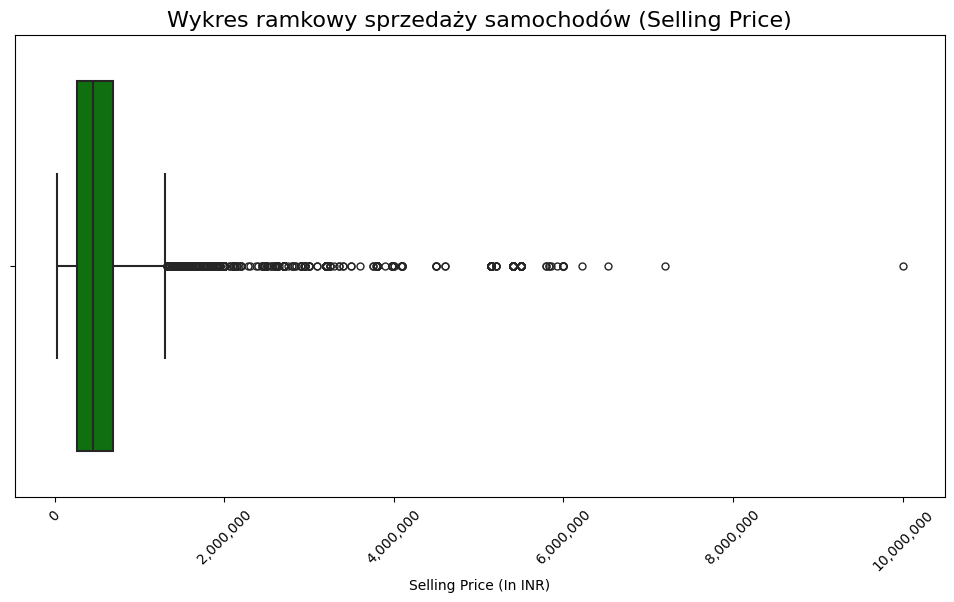

In [15]:
formatter = FuncFormatter(lambda x, pos: f'{int(x):,}')
plt.figure(figsize=(12, 6))
plt.title('Wykres ramkowy sprzedaży samochodów (Selling Price)', fontsize=16)
ax = sns.boxplot(x=cleaned_df['selling_price'],native_scale=True,color='green', fliersize=5, linewidth=1.5)

# ax.set_xscale('log')  # Ustawienie skali logarytmicznej dla lepszej wizualizacji

ax.xaxis.set_major_formatter(formatter)
plt.xticks(rotation=45)
plt.xlabel('Selling Price (In INR)')
plt.show()

Wykres ramka-wąsy pokazuje, że większość danych  jest skupiona po lewej stronie, przy niższych cenach. Oznacza to, że większość oferowanych samochodów ma stosunkowo niską cenę sprzedaży, która nie przekracza wartości 1,000,000 INR. Liczne wartości odstające - długi "wąs" i liczne kropki po prawej stronie reprezentują samochody, których cena jest znacznie wyższa od wartości średniej. Są to wartości odstające. W zbiorze danych opartym na sprzedaży pojazdów jest to zjawisko całkowicie naturalne – większość to popularne, tańsze modele, ale w zbiorze znajduje się też niewielka liczba drogich, luksusowych aut, które zawyżają średnią i tworzą taki "ogon" na wykresie. Skrzynka jest stosunkowo wąska i znajduje się na początku skali, co potwierdza, że 50% wszystkich samochodów w zbiorze mieści się w dość małym i niskim przedziale cenowym.

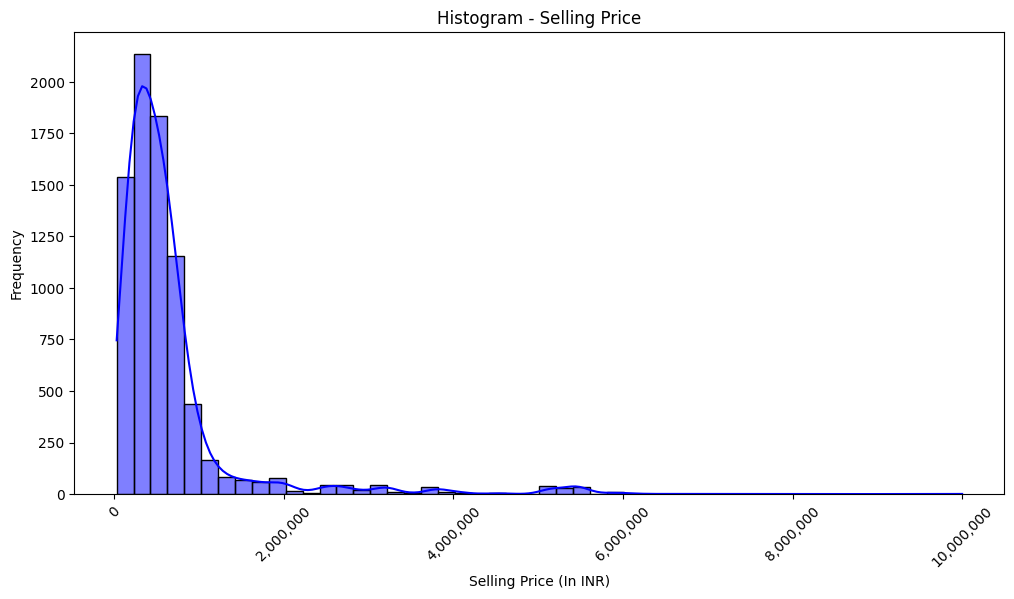

In [16]:
formatter = FuncFormatter(lambda x, pos: f'{int(x):,}')
plt.figure(figsize=(12, 6))
plt.title('Histogram - Selling Price')
ax = sns.histplot(x=cleaned_df['selling_price'],bins=50, kde=True,color='blue', edgecolor='black')

# ax.set_xscale('log')  # Ustawienie skali logarytmicznej dla lepszej wizualizacji

ax.xaxis.set_major_formatter(formatter)
plt.xticks(rotation=45)
plt.xlabel('Selling Price (In INR)')
plt.ylabel('Frequency')

plt.show()

Histogram potwierdza fakt, iż znaczna większość samochodów posiada cenę w niskim przedziale, prawdopodobnie poniżej 1,000,000 INR. W miarę wzrostu ceny, liczba samochodów gwałtownie spada. Można także dopatrzeć się wystąpienia marek wyższej półki, których cena oscyluje pomiędzy 2,000,000, a 6,000,000 INR. Podobnie jak wykres pudełkowy, histogram jednoznacznie pokazuje, że rozkład jest silnie prawostronnie skośny (positively skewed). W kontekście cen jest to całkowicie naturalne – większość produktów na rynku ma przystępną cenę, a produkty luksusowe są rzadkością.
Istnieje długi "ogon" po prawej stronie, co oznacza, że jest bardzo niewiele samochodów o bardzo wysokich cenach. Podobnie jak wykres pudełkowy, histogram jednoznacznie pokazuje, że rozkład jest silnie prawostronnie skośny. Oznacza to, że większość samochodów na tym rynku ma przystępną cenę, a produkty luksusowe są rzadkością, co jest zgodne z rzeczywistością.

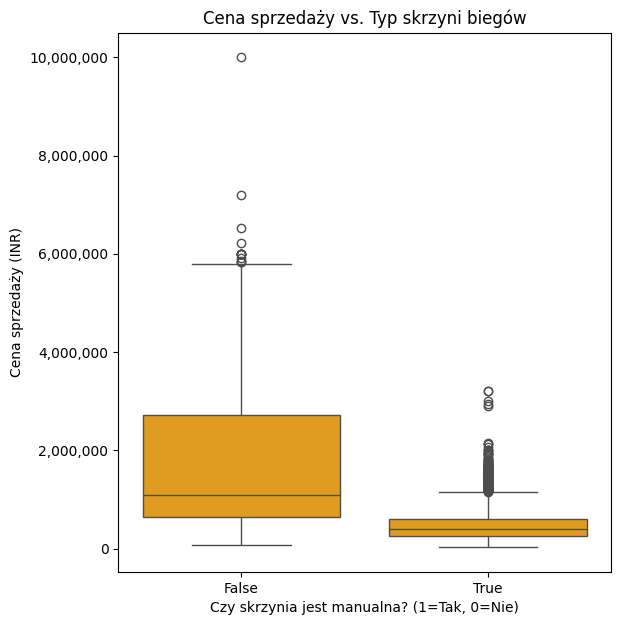

In [17]:
plt.figure(figsize=(14, 7))

# Cena w zależności od typu skrzyni biegów
plt.subplot(1, 2, 1) # 1 wiersz, 2 kolumny, 1-szy wykres
sns.boxplot(x='transmission_Manual', y='selling_price', data=cleaned_df,color='orange')
plt.title('Cena sprzedaży vs. Typ skrzyni biegów')
plt.xlabel('Czy skrzynia jest manualna? (1=Tak, 0=Nie)')
plt.ylabel('Cena sprzedaży (INR)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}')) # Formatowanie osi Y


Pierwszy jednoznacznie pokazuje, że samochody z automatyczną skrzynią biegów (False) są znacznie droższe niż te z manualną (True). Mają one wyraźnie wyższą medianę ceny oraz znacznie większy rozrzut cen, włączając w to najdroższe modele w zbiorze.

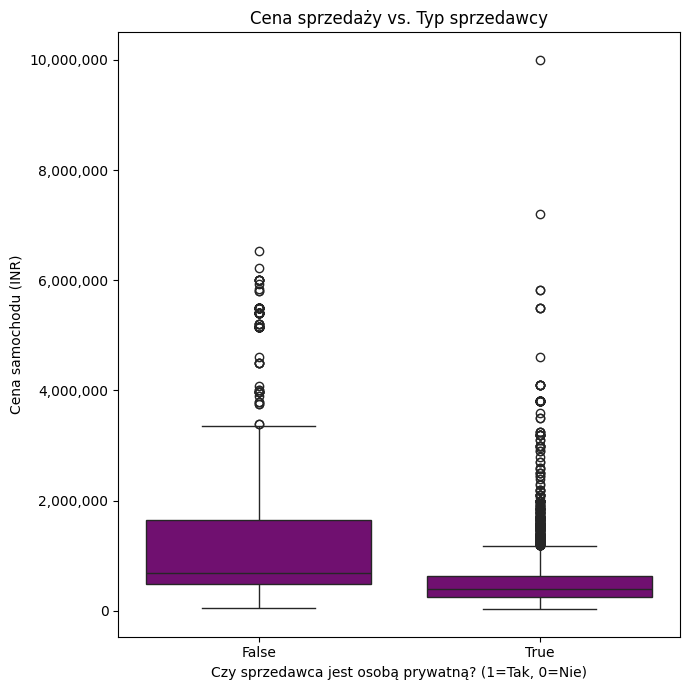

In [18]:
# Cena w zależności od typu sprzedawcy
plt.figure(figsize=(7, 7))
sns.boxplot(x='seller_type_Individual', y='selling_price', data=cleaned_df,color='purple')
plt.title('Cena sprzedaży vs. Typ sprzedawcy')
plt.xlabel('Czy sprzedawca jest osobą prywatną? (1=Tak, 0=Nie)')
plt.ylabel('Cena samochodu (INR)') # Usuwamy etykietę Y, bo jest taka sama
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}')) # Formatowanie osi Y
plt.tight_layout()
plt.show()

Drugi wykres pokazuje, że samochody oferowane przez dealerów (False) są statystycznie droższe niż te sprzedawane przez osoby prywatne (True). Ceny u dealerów mają wyższą medianę i szerszy zakres, podczas gdy sprzedaż prywatna jest skoncentrowana w niższym przedziale cenowym.

# Wnioskowanie statystyczne


In [19]:
alpha = 0.05
test_set = cleaned_df['selling_price'].sample(frac=0.2, random_state=420321)  # Próbka 20% danych do testu normalności
print(f"\nKształt zbioru testowego: {len(test_set)} wierszy oraz 25 kolumn.")
print(f"\nH0: Rozkład Selling Price jest rozkładem normalnym.\nH1: Rozkład Selling Price nie jest rozkładen normalnym.\nPoziom istotności(alpha): {alpha}")

# Test Shapiro-Wilka dla normalności rozkładu

shapiro_test = scipy.stats.shapiro(test_set)
print("\n--- Test Shapiro-Wilka dla normalności rozkładu Selling Price ---")
print(f"Statystyka testu: {shapiro_test.statistic}, p-wartość: {shapiro_test.pvalue}")

if shapiro_test.pvalue < alpha:
    print("Odrzucamy hipotezę zerową: Rozkład Selling Price nie jest rozkładem normalnym.")
else:
    print("Nie odrzucamy hipotezy zerowej: Rozkład Selling Price jest jest rozkładem normalnym.")


Kształt zbioru testowego: 1581 wierszy oraz 25 kolumn.

H0: Rozkład Selling Price jest rozkładem normalnym.
H1: Rozkład Selling Price nie jest rozkładen normalnym.
Poziom istotności(alpha): 0.05

--- Test Shapiro-Wilka dla normalności rozkładu Selling Price ---
Statystyka testu: 0.5562622173424496, p-wartość: 7.082010515137876e-53
Odrzucamy hipotezę zerową: Rozkład Selling Price nie jest rozkładem normalnym.


Wynik testu dał p-wartość znacznie mniejszą od 0.05. Oznacza to, że mamy mocne podstawy do odrzucenia hipotezy zerowej. Oznacza to, rozkład cen samochodów w badanym zbiorze nie jest rozkładem normalnym, co potwierdzają również wcześniejsze obserwacje z histogramu (silna prawostronna skośność). Naruszenie założenia o normalności może mieć wpływ na interpretację testów istotności w klasycznej regresji liniowej, jednak dla celów predykcyjnych w uczeniu maszynowym nie jest to krytyczne ograniczenie."

# Macierz korelacji

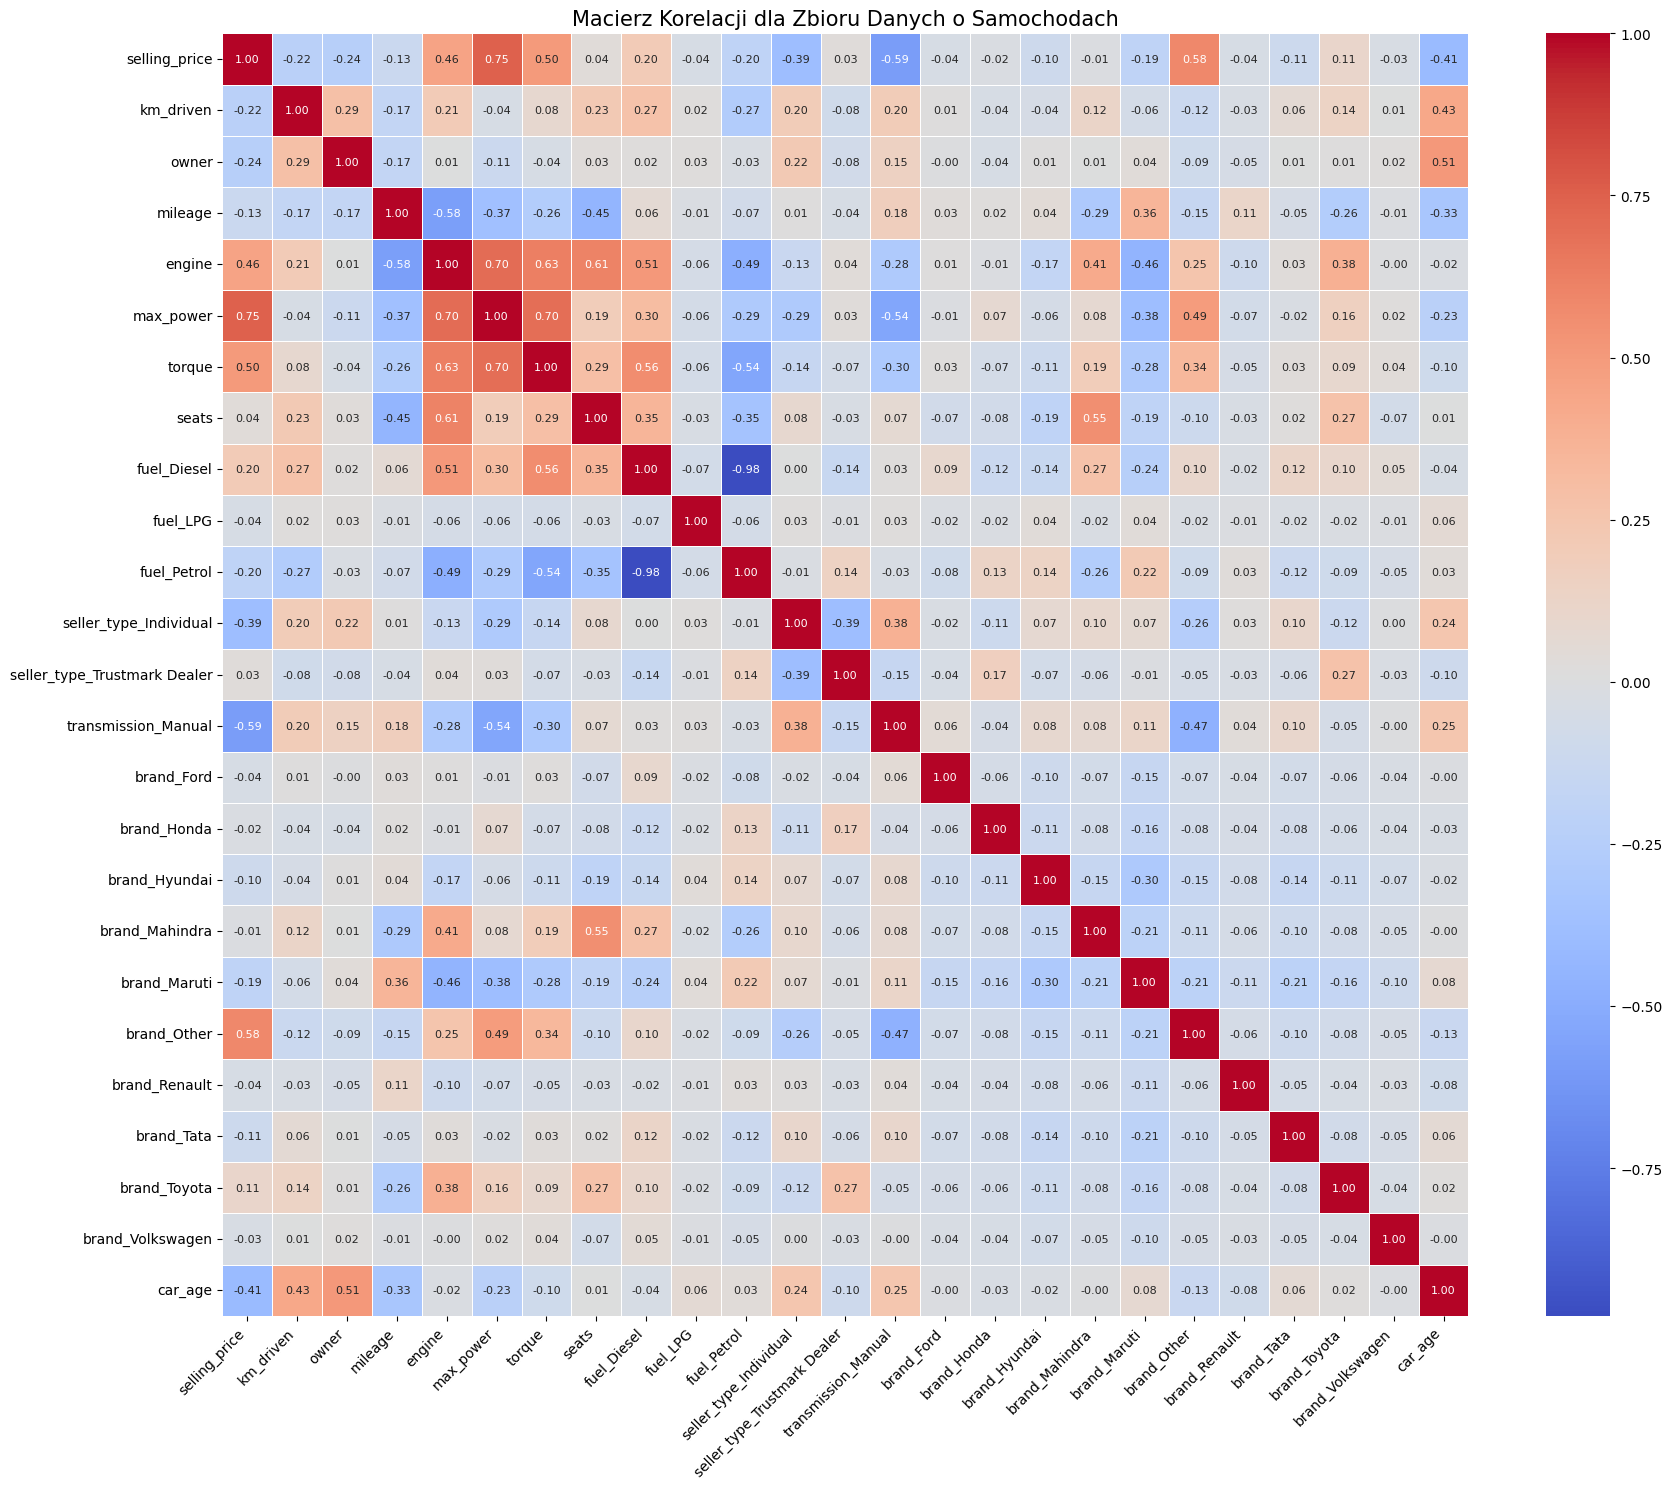

In [20]:
corr_matrix = cleaned_df.corr(method='pearson')
plt.figure(figsize=(18, 15)) # Rozmiar można dostosować
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8})
plt.title('Macierz Korelacji dla Zbioru Danych o Samochodach', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout() # Dopasowanie układu, aby etykiety się nie nakładały
plt.show()

**Najsilniejsze korelacje POZYTYWNE (im wyższa wartość, tym wyższa cena):**

    max_power (moc silnika): +0.75

To najsilniejszy pozytywny wskaźnik. Oznacza to, że samochody o większej mocy (BHP) są zdecydowanie droższe. To bardzo intuicyjne.

    brand_Other (inna marka): +0.58

To bardzo ciekawa korelacja. Zmienna "inna marka" grupuje rzadsze, bardziej luksusowe marki, które nie dostały własnej kolumny. Dlatego, jeśli samochód należy do tej kategorii, jego cena jest znacznie wyższa - prawdopodobnie związane jest to z zjawiskiem prestiżu.

    torque (moment obrotowy): +0.50

Podobnie jak moc, wyższy moment obrotowy jest cechą droższych, mocniejszych samochodów.

    engine (pojemność silnika): +0.46

Samochody z większą pojemnością silnika (CC) mają tendencję do bycia droższymi. Jest to korelacja umiarkowana, ale wciąż znacząca.

**Najsilniejsze korelacje NEGATYWNE (im wyższa wartość, tym niższa cena):**

    transmission_Manual (manualna skrzynia biegów): -0.59

To najsilniejsza korelacja negatywna. Oznacza, że jeśli samochód ma manualną skrzynię biegów (transmission_Manual = 1), jego cena jest wyraźnie niższa. Oznacza to, że w tym zbiorze danych samochody z automatyczną skrzynią biegów są droższe.

    car_age (wiek samochodu): -0.41

Bardzo logiczna zależność. Im starszy samochód (im wyższy wiek), tym jego cena sprzedaży jest niższa.

    seller_type_Individual (sprzedawca indywidualny): -0.39

Ceny samochodów sprzedawanych przez osoby prywatne są statystycznie niższe niż te oferowane przez dealerów.

    km_driven (przejechane kilometry): -0.22

Większy przebieg jest związany z niższą ceną, ale co ciekawe, ta korelacja jest słabsza niż w przypadku wieku auta czy rodzaju skrzyni biegów.

# Model regresji liniowej jednej zmiennej i wielorakiej:


Regresja liniowa jednej zmiennej - selling_price ~ max_power

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

In [22]:

Y = cleaned_df['selling_price']

simple_regression_features = ['max_power'] 
simple_regression_features = [col for col in simple_regression_features if col in cleaned_df.columns]

for feature_name in simple_regression_features:
        print(f"\n--- Model: selling_price ~ {feature_name} ---")
        X_simple = cleaned_df[[feature_name]] # Musi być DataFrame (dwie pary nawiasów kwadratowych)

        # Podział na zbiór treningowy i testowy
        X_train_simple, X_test_simple, Y_train, Y_test = train_test_split(X_simple, Y, test_size=0.2, random_state=42)

        # Budowa i trenowanie modelu
        model_simple = LinearRegression()
        model_simple.fit(X_train_simple, Y_train)

        # Współczynniki modelu
        print(f"Intercept (b0): {model_simple.intercept_:.2f}")
        print(f"Współczynnik dla {feature_name} (b1): {model_simple.coef_[0]:.2f}")
        print(f"Równanie: selling_price = {model_simple.intercept_:.2f} + ({model_simple.coef_[0]:.2f} * {feature_name})")

        # Prognozy
        Y_pred_train_simple = model_simple.predict(X_train_simple)
        Y_pred_test_simple = model_simple.predict(X_test_simple)

        # Ocena modelu
        r2_train_simple = r2_score(Y_train, Y_pred_train_simple)
        r2_test_simple = r2_score(Y_test, Y_pred_test_simple)
        rmse_test_simple = np.sqrt(mean_squared_error(Y_test, Y_pred_test_simple))
        mae_test_simple = mean_absolute_error(Y_test, Y_pred_test_simple)

        print(f"R^2 (treningowy): {r2_train_simple:.2f}")
        print(f"R^2 (testowy): {r2_test_simple:.2f}")
        print(f"RMSE (testowy): {rmse_test_simple:.2f}")
        print(f"MAE (testowy): {mae_test_simple:.2f}")




--- Model: selling_price ~ max_power ---
Intercept (b0): -889453.88
Współczynnik dla max_power (b1): 16787.57
Równanie: selling_price = -889453.88 + (16787.57 * max_power)
R^2 (treningowy): 0.55
R^2 (testowy): 0.59
RMSE (testowy): 531943.43
MAE (testowy): 307337.23


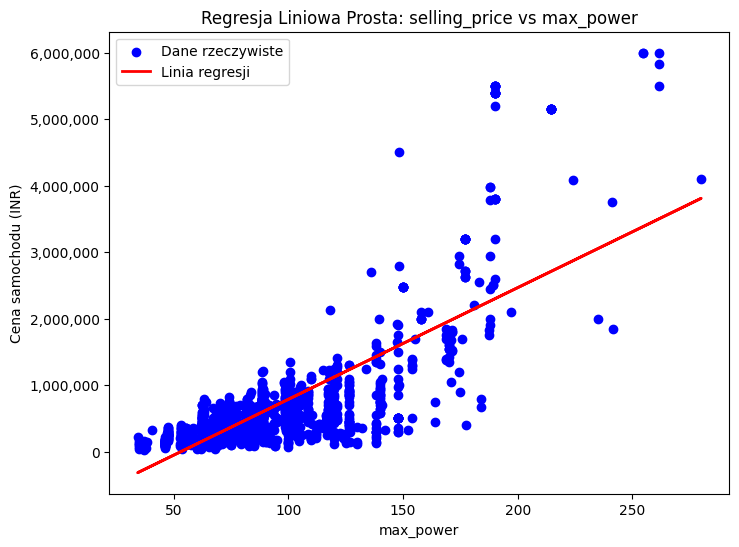

In [23]:
# Wizualizacja (nieobowiązkowa, ale może być przydatna)
plt.figure(figsize=(8, 6))
plt.scatter(X_test_simple, Y_test, color='blue', label='Dane rzeczywiste')
plt.plot(X_test_simple, Y_pred_test_simple, color='red', linewidth=2, label='Linia regresji')
plt.xlabel(feature_name)
plt.ylabel('Cena samochodu (INR)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}')) # Formatowanie osi Y
plt.title(f'Regresja Liniowa Prosta: selling_price vs {feature_name}')
plt.legend()
plt.show()

Regresja liniowa wielu zmiennych:


In [24]:
multiple_regression_features = cleaned_df.drop(columns=['selling_price']).columns.tolist()

# mamy dużą korelacje między 'engine','max_power' i 'torque', więc usuwamy je, aby poprawić stabilność modelu

multiple_regression_features= cleaned_df.drop(columns=['selling_price', 'engine', 'torque'])

X_multiple_cols = [col for col in multiple_regression_features if col in cleaned_df.columns]


In [25]:
X_multiple = cleaned_df[X_multiple_cols]
print("Wybrane cechy do modelu wielorakiego:", X_multiple_cols)

# Podział na zbiór treningowy i testowy
X_train_multi, X_test_multi, Y_train_multi, Y_test_multi = train_test_split(X_multiple, Y, test_size=0.2, random_state=42)

# Budowa i trenowanie modelu
model_multi = LinearRegression()
model_multi.fit(X_train_multi, Y_train_multi)

# Współczynniki modelu
print(f"\nIntercept (b0): {model_multi.intercept_:.2f}")
print("Współczynniki (b1, b2, ...):")
for feature, coef in zip(X_multiple_cols, model_multi.coef_):
  print(f"  {feature}: {coef:.2f}")

# Prognozy
Y_pred_train_multi = model_multi.predict(X_train_multi)
Y_pred_test_multi = model_multi.predict(X_test_multi)

# Ocena modelu
r2_train_multi = r2_score(Y_train_multi, Y_pred_train_multi)
r2_test_multi = r2_score(Y_test_multi, Y_pred_test_multi)
rmse_test_multi = np.sqrt(mean_squared_error(Y_test_multi, Y_pred_test_multi))
mae_test_multi = mean_absolute_error(Y_test_multi, Y_pred_test_multi)

print(f"\nR^2 (treningowy): {r2_train_multi:.2f}")
print(f"R^2 (testowy): {r2_test_multi:.2f}")
print(f"RMSE (testowy): {rmse_test_multi:.2f}")
print(f"MAE (testowy): {mae_test_multi:.2f}")

# Błędy modelu

print("\nMetryki dla modelu regresji wielorakiej:")
print(f"  R^2 (testowy): {r2_test_multi:.2f}")
print(f"  RMSE (testowy): {rmse_test_multi:.2f}")
print(f"  MAE (testowy): {mae_test_multi:.2f}")


Wybrane cechy do modelu wielorakiego: ['km_driven', 'owner', 'mileage', 'max_power', 'seats', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Mahindra', 'brand_Maruti', 'brand_Other', 'brand_Renault', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen', 'car_age']

Intercept (b0): 312184.39
Współczynniki (b1, b2, ...):
  km_driven: -1.29
  owner: -21198.08
  mileage: 7457.33
  max_power: 11918.73
  seats: -21278.82
  fuel_Diesel: 70362.37
  fuel_LPG: 223536.81
  fuel_Petrol: -15173.73
  seller_type_Individual: -180574.33
  seller_type_Trustmark Dealer: -251892.78
  transmission_Manual: -302529.27
  brand_Ford: -13763.19
  brand_Honda: -108286.84
  brand_Hyundai: -5909.47
  brand_Mahindra: 84556.77
  brand_Maruti: 147588.37
  brand_Other: 592743.39
  brand_Renault: 22158.88
  brand_Tata: -69072.32
  brand_Toyota: 284305.27
  brand_Volkswagen: -139407.38
  car_age:

Interpretacja niektórych wyników:
1. max_power: +11918.73 -> Każdy dodatkowy BHP podnosi cenę o ~12 tys. INR. Bardzo silny, pozytywny wpływ.
2. transmission_Manual: -302529.27 -> Manualna skrzynia biegów obniża przewidywaną cenę aż o ~302 tys. INR w porównaniu do automatu. To kluczowy czynnik.
3. car_age: -35068.25 -> Każdy rok "starości" obniża cenę o ~35 tys. INR.
4. seller_type_Individual: -180574.33 -> Samochód od osoby prywatnej jest średnio o ~180 tys. INR tańszy niż od dealera (kategorii bazowej).
5. brand_Other: +592743.39 -> Samochody rzadkich, luksusowych marek są średnio o ~593 tys. INR droższe, co w kontekscie obecnej sytuacji ekonomicznej ma sens.

## Drzewa Decyzyjne zamiast regresji liniowej ##


In [26]:

model_tree = DecisionTreeRegressor(max_depth=8, random_state=42)
model_tree.fit(X_train_multi, Y_train_multi)

Y_pred_train_tree = model_tree.predict(X_train_multi)
Y_pred_test_tree = model_tree.predict(X_test_multi)

r2_train_tree = r2_score(Y_train_multi, Y_pred_train_tree)
rmse_train_tree = np.sqrt(mean_squared_error(Y_train_multi, Y_pred_train_tree))
mae_train_tree = mean_absolute_error(Y_train_multi, Y_pred_train_tree)

r2_test_tree = r2_score(Y_test_multi, Y_pred_test_tree)
rmse_test_tree = np.sqrt(mean_squared_error(Y_test_multi, Y_pred_test_tree))
mae_test_tree = mean_absolute_error(Y_test_multi, Y_pred_test_tree)

print("--- Wyniki dla Drzewa Decyzyjnego ---")

print(f"R^2 (treningowy): {r2_train_tree:.2f}")
print(f"RMSE (treningowy): {rmse_train_tree:.2f}")
print(f"MAE (treningowy): {mae_train_tree:.2f}\n")

print(f"R^2 (testowy): {r2_test_tree:.2f}")
print(f"RMSE (testowy): {rmse_test_tree:.2f}")
print(f"MAE (testowy): {mae_test_tree:.2f}")


--- Wyniki dla Drzewa Decyzyjnego ---
R^2 (treningowy): 0.98
RMSE (treningowy): 122852.07
MAE (treningowy): 79850.13

R^2 (testowy): 0.96
RMSE (testowy): 156718.29
MAE (testowy): 90200.49


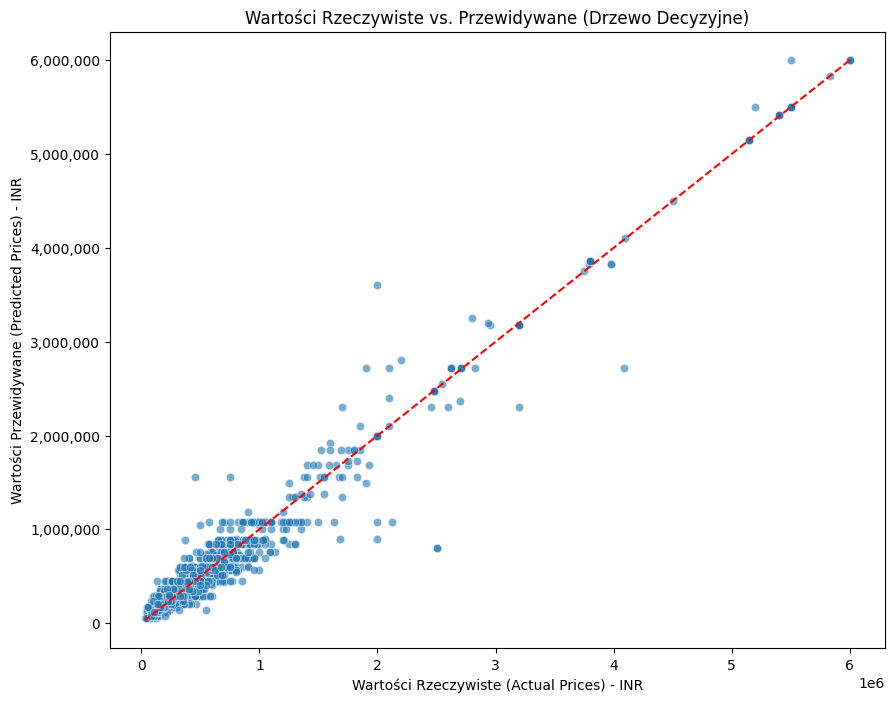

In [27]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=Y_test_multi, y=Y_pred_test_tree, alpha=0.6)
# Dodanie linii y=x
p1 = max(max(Y_pred_test_tree), max(Y_test_multi))
p2 = min(min(Y_pred_test_tree), min(Y_test_multi))
plt.plot([p1, p2], [p1, p2], 'r--')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}')) # Formatowanie osi Y
plt.title('Wartości Rzeczywiste vs. Przewidywane (Drzewo Decyzyjne)')
plt.xlabel('Wartości Rzeczywiste (Actual Prices) - INR')
plt.ylabel('Wartości Przewidywane (Predicted Prices) - INR')
plt.show()

# Oceny modeli i porównanie:

In [28]:
# Tabela porównująca modele
results_df = pd.DataFrame({
    'Model': ['Regresja Liniowa Prosta', 'Regresja Liniowa Wieloraka', 'Drzewo Decyzyjne'],
    'R^2 (testowy)': [r2_test_simple, r2_test_multi, r2_test_tree],
    'RMSE (testowy)': [rmse_test_simple, rmse_test_multi, rmse_test_tree],
    'MAE (testowy)': [mae_test_simple, mae_test_multi, mae_test_tree]
})

print("--- Porównanie wyników modeli ---")
print(results_df.round(2))

--- Porównanie wyników modeli ---
                        Model  R^2 (testowy)  RMSE (testowy)  MAE (testowy)
0     Regresja Liniowa Prosta        0.59000    531943.43000   307337.23000
1  Regresja Liniowa Wieloraka        0.74000    421791.85000   245685.21000
2            Drzewo Decyzyjne        0.96000    156718.29000    90200.49000


Model regresji prostej, oparty tylko na mocy silnika, osiągnął R² na poziomie 0.59, co oznacza, że sama moc wyjaśnia 59% zmienności cen. Jest to przyzwoity wynik jak na jedną zmienną.
Model regresji wielorakiej znacząco poprawił wyniki (R² ≈ 0.74), co dowodzi, że uwzględnienie dodatkowych cech, takich jak wiek auta czy typ skrzyni biegów, pozwoliło na lepsze dopasowanie. Błędy RMSE i MAE również uległy zmniejszeniu.
Model drzewa decyzyjnego okazał się zdecydowanie najlepszy, osiągając R² na poziomie 0.96. Oznacza to, że model ten, dzięki zdolności do wychwytywania nieliniowych zależności, wyjaśnia aż 96% zmienności cen. Jego błędy predykcji (RMSE i MAE) są również najniższe spośród wszystkich modeli."

# Wnioski  

Celem projektu było zbadanie czynników wpływających na cenę używanych samochodów w Indiach i zbudowanie modelu predykcyjnego. Cel ten został w pełni osiągnięty. Analiza korelacji oraz ocena modeli wykazały, że kluczowymi predyktorami ceny są:
- Moc silnika (max_power) - najsilniejszy pozytywny wpływ.

- Wiek samochodu (car_age) i typ skrzyni biegów (transmission_Manual) - najsilniejsze czynniki obniżające cenę.

- Inne istotne czynniki to pojemność silnika, marka oraz to, czy sprzedawcą jest osoba prywatna.

Spośród przetestowanych modeli, najwyższą skuteczność predykcyjną wykazał model drzewa decyzyjnego. Jego zdolność do modelowania złożonych, nieliniowych interakcji między cechami pozwoliła na znaczne zredukowanie błędów prognozy w porównaniu do modeli liniowych. Analiza opierała się wyłącznie na danych z ogłoszeń. Model nie uwzględnia niewymiernych czynników, jak stan techniczny pojazdu czy historia serwisowa. Przykładowym krokiem w celu poprawy wyników mogłoby być zastosowanie bardziej zaawansowanych modeli, takich jak Random Forest lub Gradient Boosting, które często oferują jeszcze wyższą dokładność i są bardziej odporne na przeuczenie."
